# Aprendiendo Fashion-MNIST con PyTorch

## Refs.

* https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

* https://github.com/zalandoresearch/fashion-mnist

* https://github.com/pranay414/Fashion-MNIST-Pytorch/blob/master/fashion_mnist.ipynb

## **Ejercicio 1)** Importando librerías

**0)** De ser necesario, **instale PyTorch** escribiendo

    !pip3 install torch torchvision torchaudio torchviz

**1)** Importe las librerías estandard de Python: `os`, `datetime`, `collections` y `pickle`.

**2)** Importe las siguientes librerías third party de Python: `matplotlib.pyplot`, `numpy`, `scipy`, `sklearn`, `pandas`, `dill` y `json`.

**3)** Importe las librerias necesarias de **PyTorch**: `torch` y `torchvision`.

**4)** Importe la librería: `google.colab`.

In [ ]:
# 1.0)
!pip3 install torch torchvision torchaudio torchviz

In [ ]:
# 1.1)
import os
import pickle
import datetime
from collections import defaultdict

In [ ]:
# 1.2)
import random
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import sklearn as skl
import pandas as pd
#import dill
import json

In [ ]:
# 1.3)
import torch
import torch.optim as optim
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets
from torchvision import transforms
from torchvision.io import read_image
from torchvision.transforms import ToTensor, Lambda, Compose
#from torchviz import make_dot

In [ ]:
# 1.4)
import google.colab
from google.colab import files

## **Ejercicio 2)**

Bajando y Jugando con el dataset **Fashion-MNIST**.

**1)** Baje y transforme (i.e. normalize los valores de los pixeles) los conjuntos de entrenamiento y testeo de FashionMNIST.

**2)** Explore algunos ejemplos de estos conjuntos. Que formato poseen?

**3)** Visitando la página web de FashionMNIST, cree un diccionario de Python `Dict()` asociando cada categoría a un nombre adecuado de la misma.

**4)** Grafique un mosaico de 3x3 imagenes de FashionMNIST, cada una titulada con su respectiva clasificación

### *2.1)*

In [ ]:
# Define a transform to normalize the data
transform = transforms.Compose([
                                transforms.ToTensor()
                                ,transforms.Normalize((0.5,), (0.5,))
                                #,transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                               ])

# Download and load the training data
train_set = datasets.FashionMNIST('MNIST_data/', download = True, train = True,  transform = transform)
valid_set = datasets.FashionMNIST('MNIST_data/', download = True, train = False, transform = transform)


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.5MB/s]


### *2.2)*

Tipo de img_tensor: <class 'torch.Tensor'>
Shape (C,H,W): torch.Size([1, 28, 28])
Rango de valores (tensor normalizado): -1.0 → 1.0
Etiqueta (numérica): 9


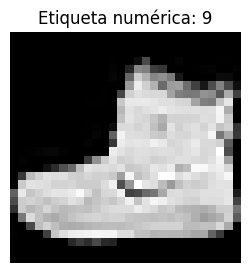

In [ ]:
# Tomamos un ejemplo del dataset de entrenamiento
img_tensor, label = train_set[0]  # img_tensor: torch.Tensor de forma (1,28,28), label: int

print("Tipo de img_tensor:", type(img_tensor))
print("Shape (C,H,W):", img_tensor.shape)  # debería ser (1,28,28)
print("Rango de valores (tensor normalizado):",
      img_tensor.min().item(), "→", img_tensor.max().item())
print("Etiqueta (numérica):", label)

# Para visualizar con matplotlib necesitamos convertir el tensor a numpy y "desnormalizar"
def tensor_to_image(tensor):
    # tensor tiene shape (1,28,28) y está normalizado en [-1,1]
    tensor = tensor.clone()       # evitar modificar el original
    tensor = tensor * 0.5 + 0.5   # desnormalizar a [0,1]
    array = tensor.numpy()        # convertir a numpy
    array = np.squeeze(array)     # quitar dimensión de canal -> shape (28,28)
    return array

# Mostrar una imagen de ejemplo
sample_img = tensor_to_image(img_tensor)
plt.figure(figsize=(3,3))
plt.imshow(sample_img, cmap='gray')
plt.title(f"Etiqueta numérica: {label}")
plt.axis('off')
plt.show()


In [ ]:
print(train_set.data[0])

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
           0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,   1,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   0,
          36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,   0,   3],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,
         102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,  10,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

+ Hay valores entre 0 y 255 para cada imagen, por lo tanto se trata de una imagen en blanco y negro que se representa utilizando la escala de grises.

In [ ]:
print(train_set.targets[0])

tensor(9)


### *2.3)*

In [ ]:
# Diccionario de clases de Fashion-MNIST
class_names = dict(enumerate(train_set.classes))
print("Diccionario de clases:", class_names)

Diccionario de clases: {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


### *2.4)*

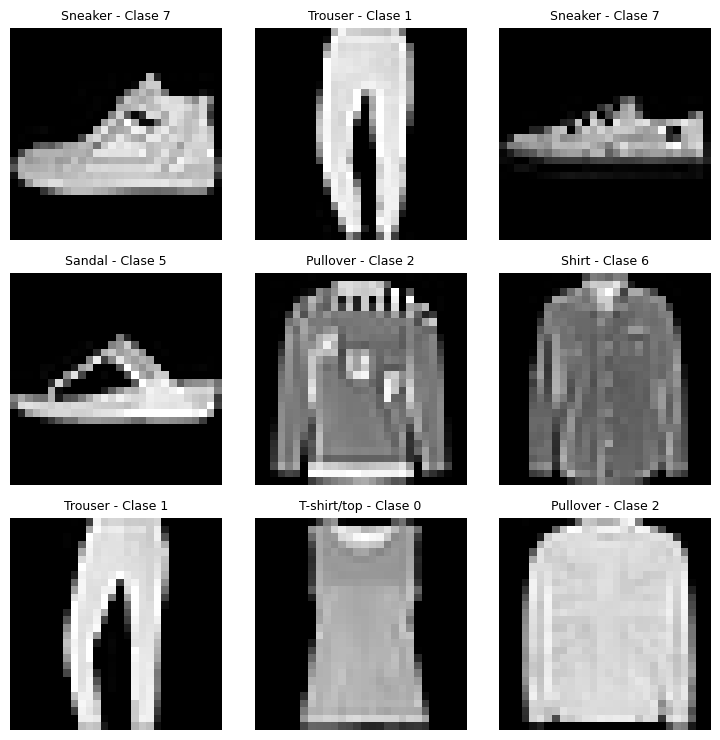

In [ ]:
# Graficar un mosaico 3x3 de imágenes aleatorias con sus nombres
def plot_grid(dataset, class_dict, rows =3, cols =3, seed =123):
    random.seed(seed)
    indices = random.sample ( range (len(dataset)), rows * cols)
    fig, axes = plt.subplots (rows, cols, figsize = (cols * 2.5, rows * 2.5))
    for ax, idx in zip(axes.flatten(), indices):
        img_t, lbl = dataset[idx]
        img = tensor_to_image(img_t)
        ax.imshow (img, cmap ='gray')
        ax.set_title(f"{class_dict[int(lbl)]} - Clase {lbl}", fontsize=9)
        ax.axis ('off')
    plt.tight_layout()
    plt.show()

plot_grid(train_set, class_names, rows=3, cols=3)

## Ejercicio 3)

Creando un `DataLoader` para alimentar el modelo con batchs (lotes) de entrenamiento.

**1)** Cree los `DataLoader`s para cada conjunto. Defínalos con un `batch_size` de 100 y con el flag `shuffle` seteado a `True`.

**2)** Use uno de los `DataLoader`s creados anteriormente para explorar algunos elementos del conjunto.

Notar que, el iterador devuelve el batch en un par `(image,label)`.

El objeto `images` es un tensor de dimensiones `(100,1,28,28)`.
El 100 es el tamaño del batch.
El 1 porque hay un solo canal (en este caso, un canal de escala de grises, pero podría haber varios, p. ej. uno por cada color de {Red, Green Blue} en caso que fuesen imagenes a color).
Luego, 28 y 28 porque cada imagen del dataset es de 28 x 28 píxeles.

El objeto `labels` es un tensor de dimensiones `(100,)`.
La $i$-ésima entrada `labels[i]` de `labels` es un número en $\{0,1,...,9\}$ indicando la categoría a la que pertenece la $i$-ésima imagen en el batch, guardada en `images[i]`.

### *3.1)*

In [ ]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size = 100, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size = 100, shuffle = True)

### 3.2)

In [ ]:
images, labels = next(iter(train_loader))

print("shape de images:",images.shape)
print("shape de labels:",labels.shape)

shape de images: torch.Size([100, 1, 28, 28])
shape de labels: torch.Size([100])


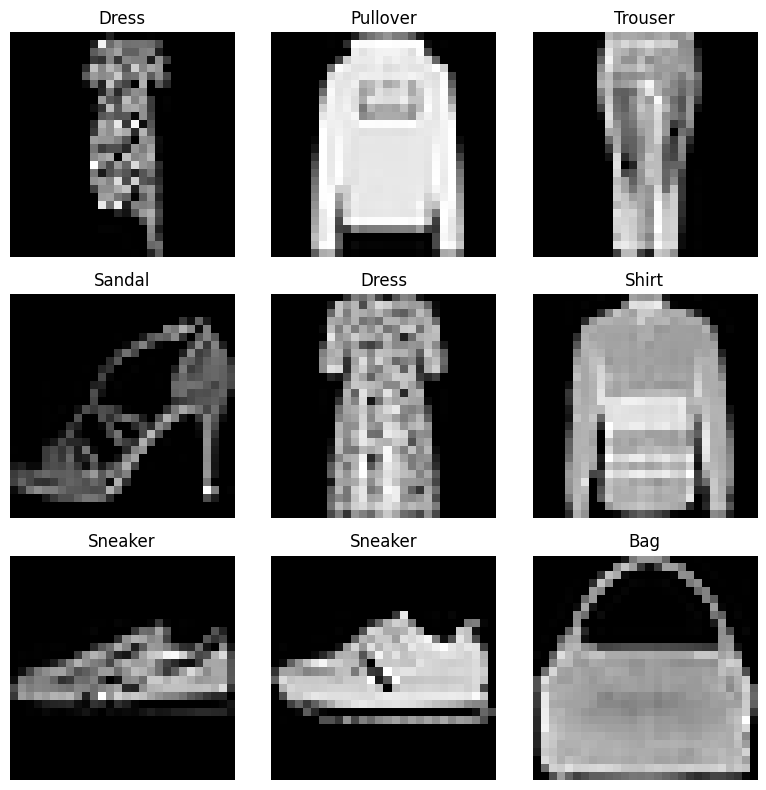

In [ ]:
# Graficar las primeras 9 imágenes del batch

fig , axes = plt.subplots(3, 3, figsize =(8, 8))
for i, ax in enumerate (axes.flatten()):
    img = tensor_to_image(images[i])
    label = labels[i].item()
    ax.imshow(img, cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

## Ejercicio 4)

Defina una red neuronal de 4 capas, una de entrada, dos ocultas de $n_1=128$ y $n_2=64$ neuronas, respectivamente, y una de salida de 10 neuronas.

En las capas intermedias utilice neuronas tipo ReLU y agregueles un *dropout* de p=0.2.
En la capa de salida no utilice funciones de activación ni dropout.

Las capas sucesivas tienen que estar totalmente conectadas entre si.

In [ ]:
# Definición de la red neuronal
class FeedforwardNN(nn.Module):
    def __init__(self,n1=128, n2=64, p=0.2):
        super(FeedforwardNN, self).__init__()

        # Capa de entrada: 784 -> 128
        self.fc1 = nn.Linear(784, n1)
        self.dropout1 = nn.Dropout(p)

        # Capa oculta: 128 -> 64
        self.fc2 = nn.Linear(n1, n2)
        self.dropout2 = nn.Dropout(p)

        # Capa de salida: 64 -> 10
        self.fc3 = nn.Linear(n2, 10)

    def forward(self, x):
        # Aplanar imagen: (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.view(x.size(0), -1)

        # Primera capa oculta
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)

        # Segunda capa oculta
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)

        # Capa de salida (sin activación, porque CrossEntropyLoss la aplica internamente)
        x = self.fc3(x)
        return x

# Para crear el modelo:
model = FeedforwardNN()
print(model)


FeedforwardNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


## Ejercicio 5)

Entrenamos el modelo

**1)** Implemente, en una función, un loop de entrenamiento que recorra los batchs (lotes).

**2)** Implemente, en una función, un loop de validación que recorra los batchs.

**3)** Inicialize dos `DataLoader`s llamados `train_loader` y `valid_loader` a partir del `train_set` (conjunto de entranmiento) y del `valid_set` (conjunto de validación) de Fashion-MNIST, respectivamente, y que usen batchs de 100 ejemplos.

**4)** Cree una función de pérdida usando la **Cross Entropy Loss**.

**IMPORTANTE:** Notar que la **Cross Entropy Loss** aplica automáticamente una `log_softmax`.

**5)** Cree un optimizador que utilice el método de **Stochastic Gradient Descent** con un learning rate igual a $10^{-3}$.

**6)** Cree una instancia del modelo.

**7)** Especifique en que dispositivo (`device`) va a trabajar: en una **CPU** o en una **GPU**.

**8)** Implemente un loop de entrenamiento y validación que trabaje con el `train_loader` y el `valid_loader`, respectivamente, usando un numero arbitrario de épocas.
Este loop debe guardar en cuatro listas los valores de los promedios del **Cross Entropy Loss** y las fracciones de clasificaciones correctas o **precisión** (accuracy) sobre el conjunto de **entrenamiento** y el de **validación**, respectivamente.

**IMPORTANTE:** No olvide copiar los batchs al dispositivo de trabajo.

**9)** Entrene y valide el modelo.

**10)** Use las listas del inciso anterior para graficar en función de las épocas la **Cross Entropy Loss** de **entrenamiento** y de **validación**.
Realize un gráfico análogo pero con la **precisión**.
Discuta y comente, cual es el número óptimo de épocas de entrenamiento?

**11)** Repita los experimentos variando hiperparámetros. Por ejemplo:

- El learning-rate.
- El optimizador (ej. puede usar ADAM).
- El valor de dropout.
- El número de neuronas en las capas intermedias.
- El número de épocas de entrenamiento.
- El tamaño de los lotes.

Discuta los resultados.

In [ ]:
#5.1)
# 2) Función de entrenamiento
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy



In [ ]:
#5.2)
def validate(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


In [ ]:
#5.3=
train_loader = torch.utils.data.DataLoader(train_set, batch_size = 100, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size = 100, shuffle = True)


In [ ]:
# 5.4) Función de pérdida
# loss_fn = nn.CrossEntropyLoss()

# # 5.5) Optimizador
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

# # 5.6) Instanciación del modelo
# model = FeedforwardNN()

# # 5.7) Selección de dispositivo (CPU o GPU)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = model.to(device)


loss_fn = nn.CrossEntropyLoss()


model = FeedforwardNN()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


optimizer = torch.optim.SGD(model.parameters(), lr=10e-3)


In [ ]:
print(device)


cuda


In [ ]:
# 5.8 y 5.9
num_epochs = 40
train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    valid_loss, valid_acc = validate(model, valid_loader, loss_fn, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_acc)

    print(f"Época {epoch+1}:")
    print(f" Entrenamiento -> Pérdida: {train_loss:.4f}, Precisión: {train_acc:.4f}")
    print(f" Validación    -> Pérdida: {valid_loss:.4f}, Precisión: {valid_acc:.4f}")


Época 1:
 Entrenamiento -> Pérdida: 2.2062, Precisión: 0.2517
 Validación    -> Pérdida: 2.0712, Precisión: 0.3750
Época 2:
 Entrenamiento -> Pérdida: 1.9396, Precisión: 0.3404
 Validación    -> Pérdida: 1.7601, Precisión: 0.3777
Época 3:
 Entrenamiento -> Pérdida: 1.6580, Precisión: 0.4446
 Validación    -> Pérdida: 1.4770, Precisión: 0.6024
Época 4:
 Entrenamiento -> Pérdida: 1.4172, Precisión: 0.5501
 Validación    -> Pérdida: 1.2375, Precisión: 0.6877
Época 5:
 Entrenamiento -> Pérdida: 1.2231, Precisión: 0.5994
 Validación    -> Pérdida: 1.0588, Precisión: 0.7042
Época 6:
 Entrenamiento -> Pérdida: 1.0869, Precisión: 0.6305
 Validación    -> Pérdida: 0.9409, Precisión: 0.7155
Época 7:
 Entrenamiento -> Pérdida: 0.9953, Precisión: 0.6524
 Validación    -> Pérdida: 0.8640, Precisión: 0.7215
Época 8:
 Entrenamiento -> Pérdida: 0.9316, Precisión: 0.6689
 Validación    -> Pérdida: 0.8125, Precisión: 0.7277
Época 9:
 Entrenamiento -> Pérdida: 0.8814, Precisión: 0.6828
 Validación    -> 

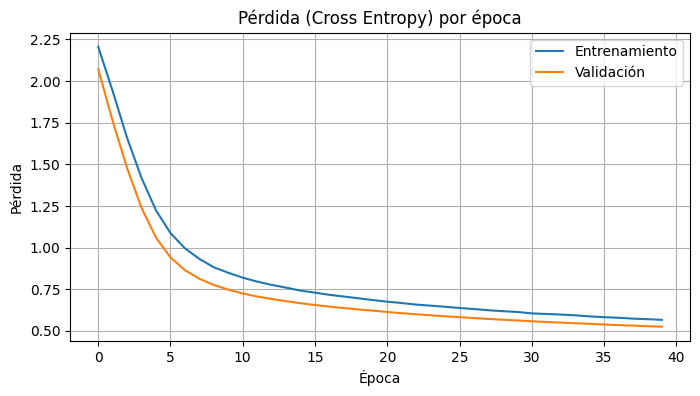

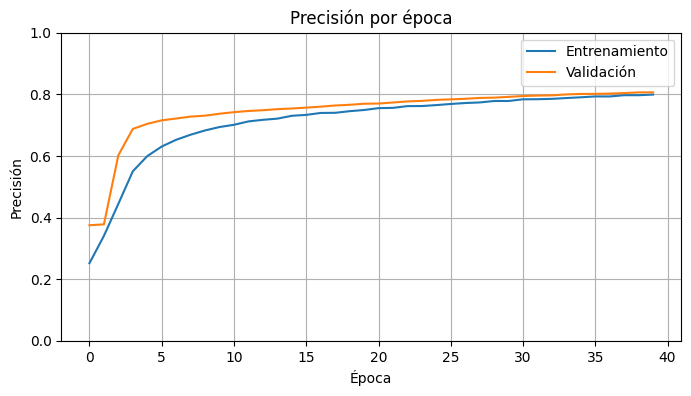

In [ ]:
#5.10)

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Entrenamiento')
plt.plot(valid_losses, label='Validación')
plt.title("Pérdida (Cross Entropy) por época")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(train_accuracies, label='Entrenamiento')
plt.plot(valid_accuracies, label='Validación')
plt.title("Precisión por época")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()


### 5.11) Variacion de parametros

In [ ]:
#para probar distintos parametros pruebo achicando el dataset


# ------ IDEA
# indices = torch.randperm(len(train_set))[:1000]
# small_train = torch.utils.data.Subset(train_set, indices)
# ------


small_train = torch.utils.data.Subset(train_set, range(0, 1000))
small_valid = torch.utils.data.Subset(valid_set, range(0, 200))

train_loader = DataLoader(small_train, batch_size=100, shuffle=True)
valid_loader = DataLoader(small_valid, batch_size=100, shuffle=False)



Entrenando con learning rate = 0.01
  Último loss de validación: 0.7713

Entrenando con learning rate = 0.005
  Último loss de validación: 1.1328

Entrenando con learning rate = 0.001
  Último loss de validación: 2.0980

Entrenando con learning rate = 0.0001
  Último loss de validación: 2.3006

Entrenando con learning rate = 1e-05
  Último loss de validación: 2.3121


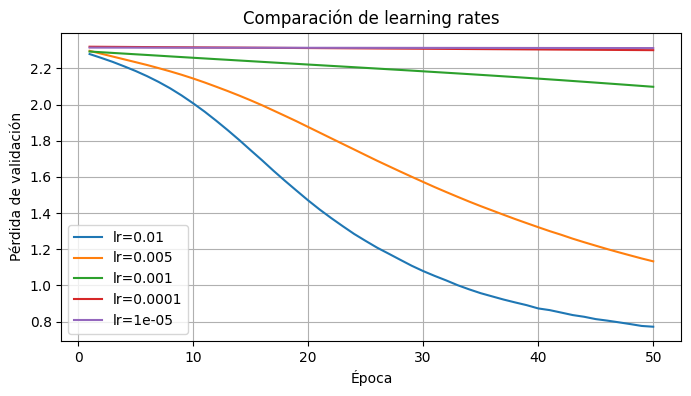

In [ ]:
learning_rates = [1e-2, 5e-3, 1e-3, 1e-4, 1e-5]
results = {}  # acá vamos a guardar las listas

for lr in learning_rates:
    print(f"\nEntrenando con learning rate = {lr}")

    model = FeedforwardNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    num_epochs = 50
    train_losses, valid_losses = [], []

    for epoch in range(num_epochs):
        train_loss, _ = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        valid_loss, _ = validate(model, valid_loader, loss_fn, device)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)

    # ahora sí guardo TODA la lista
    results[lr] = {
        "train_losses": train_losses,
        "valid_losses": valid_losses,
    }
    print(f"  Último loss de validación: {valid_losses[-1]:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
for lr in learning_rates:
    plt.plot(
        range(1, num_epochs+1),
        results[lr]["valid_losses"],
        label=f"lr={lr}"
    )
plt.xlabel("Época")
plt.ylabel("Pérdida de validación")
plt.title("Comparación de learning rates")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
# #con el conjunto un poco mas grande

# medium_train = torch.utils.data.Subset(train_set, range(0, 20000))
# medium_valid = torch.utils.data.Subset(valid_set, range(0, 4000))

# train_loader_m = DataLoader(medium_train, batch_size=100, shuffle=True)
# valid_loader_m = DataLoader(medium_valid, batch_size=100, shuffle=False)

# learning_rates = [1e-2, 5e-3, 1e-3, 1e-4, 1e-5]
# results = {}  # acá vamos a guardar las listas

# for lr in learning_rates:
#     print(f"\nEntrenando con learning rate = {lr}")

#     model = FeedforwardNN().to(device)
#     optimizer = torch.optim.SGD(model.parameters(), lr=lr)
#     loss_fn = nn.CrossEntropyLoss()

#     num_epochs = 50
#     train_losses, valid_losses = [], []

#     for epoch in range(num_epochs):
#         train_loss, _ = train_one_epoch(model, train_loader_m, loss_fn, optimizer, device)
#         valid_loss, _ = validate(model, valid_loader_m, loss_fn, device)

#         train_losses.append(train_loss)
#         valid_losses.append(valid_loss)

#     # ahora sí guardo TODA la lista
#     results[lr] = {
#         "train_losses": train_losses,
#         "valid_losses": valid_losses,
#     }
#     print(f"  Último loss de validación: {valid_losses[-1]:.4f}")


# plt.figure(figsize=(8,4))
# for lr in learning_rates:
#     plt.plot(
#         range(1, num_epochs+1),
#         results[lr]["valid_losses"],
#         label=f"lr={lr}"
#     )
# plt.xlabel("Época")
# plt.ylabel("Pérdida de validación")
# plt.title("Comparación de learning rates")
# plt.legend()
# plt.grid(True)
# plt.show()





Entrenando con optimizador: SGD
  Época 1: train_loss=2.3062  valid_loss=2.2892
  Época 2: train_loss=2.2897  valid_loss=2.2672
  Época 3: train_loss=2.2685  valid_loss=2.2433
  Época 4: train_loss=2.2424  valid_loss=2.2172
  Época 5: train_loss=2.2125  valid_loss=2.1899
  Época 6: train_loss=2.1853  valid_loss=2.1588
  Época 7: train_loss=2.1590  valid_loss=2.1249
  Época 8: train_loss=2.1241  valid_loss=2.0866
  Época 9: train_loss=2.0886  valid_loss=2.0446
  Época 10: train_loss=2.0514  valid_loss=1.9998
  Época 11: train_loss=1.9971  valid_loss=1.9490
  Época 12: train_loss=1.9434  valid_loss=1.8967
  Época 13: train_loss=1.9002  valid_loss=1.8414
  Época 14: train_loss=1.8357  valid_loss=1.7828
  Época 15: train_loss=1.7902  valid_loss=1.7231
  Época 16: train_loss=1.7308  valid_loss=1.6632
  Época 17: train_loss=1.6813  valid_loss=1.6030
  Época 18: train_loss=1.6199  valid_loss=1.5448
  Época 19: train_loss=1.5797  valid_loss=1.4869
  Época 20: train_loss=1.5101  valid_loss=1.4

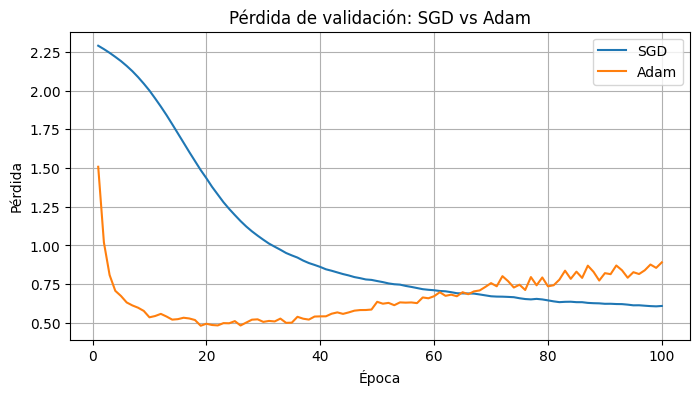

In [ ]:
#ADAM vs SGD

optimizers_to_test = {
    "SGD": lambda params: torch.optim.SGD(params, lr=1e-3, momentum=0.9),
    "Adam": lambda params: torch.optim.Adam(params, lr=1e-3),
}

results_opt = {}
num_epochs = 100

for opt_name, opt_fn in optimizers_to_test.items():
    print(f"\nEntrenando con optimizador: {opt_name}")

    # modelo nuevo para cada optimizador
    model = FeedforwardNN().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = opt_fn(model.parameters())

    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        valid_loss, valid_acc = validate(model, valid_loader, loss_fn, device)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)

        print(f"  Época {epoch+1}: train_loss={train_loss:.4f}  valid_loss={valid_loss:.4f}")

    # guardar todo
    results_opt[opt_name] = {
        "train_losses": train_losses,
        "valid_losses": valid_losses,
        "train_accs": train_accs,
        "valid_accs": valid_accs,
    }

# ============================
# Gráfico de pérdidas
# ============================
plt.figure(figsize=(8,4))
for opt_name in results_opt:
    plt.plot(
        range(1, num_epochs+1),
        results_opt[opt_name]["valid_losses"],
        label=f"{opt_name}"
    )
plt.title("Pérdida de validación: SGD vs Adam")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)
plt.show()

# ============================
# Gráfico de precisión
# ============================
# plt.figure(figsize=(8,4))
# for opt_name in results_opt:
#     plt.plot(
#         range(1, num_epochs+1),
#         results_opt[opt_name]["valid_accs"],
#         label=f"{opt_name}"
#     )
# plt.title("Precisión de validación: SGD vs Adam")
# plt.xlabel("Época")
# plt.ylabel("Precisión")
# plt.ylim(0, 1)
# plt.legend()
# plt.grid(True)
# plt.show()



Entrenando con Dropout = 0.2

Entrenando con Dropout = 0.4

Entrenando con Dropout = 0.6

Entrenando con Dropout = 0.8


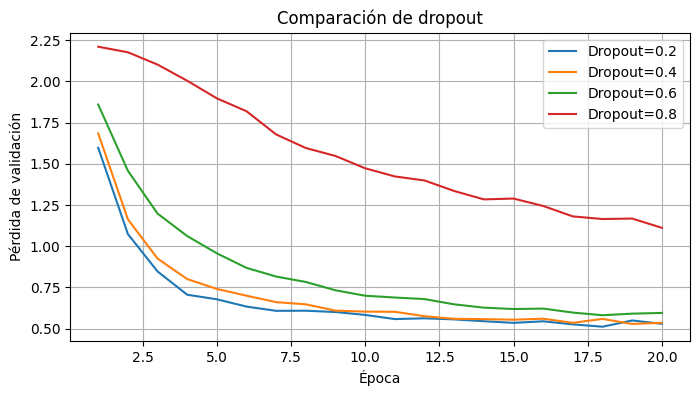

In [ ]:
#valor de dropout:

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

dropouts = [0.2, 0.4, 0.6, 0.8]
results_dropout = {}

num_epochs = 20
for p in dropouts:
    print(f"\nEntrenando con Dropout = {p}")

    # nuevo modelo con dropout distinto
    model = FeedforwardNN(p=p).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        valid_loss, valid_acc = validate(model, valid_loader, loss_fn, device)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)

    results_dropout[p] = {
        "train_losses": train_losses,
        "valid_losses": valid_losses,
        "train_accs": train_accs,
        "valid_accs": valid_accs,
    }

# ============================
# Gráfico de pérdida
# ============================
plt.figure(figsize=(8,4))
for p in dropouts:
    plt.plot(range(1, num_epochs+1),
             results_dropout[p]["valid_losses"],
             label=f"Dropout={p}")
plt.xlabel("Época")
plt.ylabel("Pérdida de validación")
plt.title("Comparación de dropout")
plt.legend()
plt.grid(True)
plt.show()

# ============================
# Gráfico de precisión
# ============================
# plt.figure(figsize=(8,4))
# for p in dropouts:
#     plt.plot(range(1, num_epochs+1),
#              results_dropout[p]["valid_accs"],
#              label=f"Dropout={p}")
# plt.xlabel("Época")
# plt.ylabel("Precisión de validación")
# plt.title("Precisión de validación según Dropout")
# plt.ylim(0, 1)
# plt.legend()
# plt.grid(True)
# plt.show()


In [ ]:
#nro de neuronas por capa

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Arquitecturas a comparar (n1, n2)
arquitecturas = [
    (64, 32),
    (128, 64),
    (256, 128),
    (512, 256)
]

results_neurons = {}
num_epochs = 20

for n1, n2 in arquitecturas:
    print(f"\nEntrenando red con arquitectura {n1}-{n2}")

    # Crear modelo con esas dimensiones
    model = FeedforwardNN(n1=n1, n2=n2, p=0.2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        valid_loss, valid_acc = validate(model, valid_loader, loss_fn, device)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)

        print(f"  Época {epoch+1:02d} | train_loss={train_loss:.4f} | val_loss={valid_loss:.4f} | val_acc={valid_acc:.4f}")

    # Guardar todas las curvas para esta arquitectura
    results_neurons[(n1, n2)] = {
        "train_losses": train_losses,
        "valid_losses": valid_losses,
        "train_accs": train_accs,
        "valid_accs": valid_accs
    }

# ============================
# Gráfico: Pérdida de validación
# ============================
plt.figure(figsize=(8,4))
for (n1, n2), values in results_neurons.items():
    plt.plot(range(1, num_epochs+1),
             values["valid_losses"],
             label=f"{n1}-{n2}")
plt.title("Evolución de la pérdida de validación por arquitectura")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend(title="Arquitectura")
plt.grid(True)
plt.show()

# ============================
# Gráfico: Precisión de validación
# ============================
plt.figure(figsize=(8,4))
for (n1, n2), values in results_neurons.items():
    plt.plot(range(1, num_epochs+1),
             values["valid_accs"],
             label=f"{n1}-{n2}")
plt.title("Evolución de la precisión de validación por arquitectura")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.ylim(0, 1)
plt.legend(title="Arquitectura")
plt.grid(True)
plt.show()


##Pruebo con el conjunto completo:

In [ ]:
train_loader_completo = DataLoader(train_set, batch_size=100, shuffle=True)
valid_loader_completo = DataLoader(valid_set, batch_size=100, shuffle=False)


Adam vs SGD:


Entrenando con optimizador: SGD
  Época 1: train_loss=0.7306  valid_loss=0.4827
  Época 2: train_loss=0.4743  valid_loss=0.4310
  Época 3: train_loss=0.4274  valid_loss=0.4036
  Época 4: train_loss=0.4061  valid_loss=0.3841
  Época 5: train_loss=0.3838  valid_loss=0.3803
  Época 6: train_loss=0.3726  valid_loss=0.3832
  Época 7: train_loss=0.3565  valid_loss=0.3733
  Época 8: train_loss=0.3462  valid_loss=0.3677
  Época 9: train_loss=0.3373  valid_loss=0.3804
  Época 10: train_loss=0.3280  valid_loss=0.3418
  Época 11: train_loss=0.3226  valid_loss=0.3574
  Época 12: train_loss=0.3169  valid_loss=0.3523
  Época 13: train_loss=0.3083  valid_loss=0.3433
  Época 14: train_loss=0.3069  valid_loss=0.3478
  Época 15: train_loss=0.2986  valid_loss=0.3338
  Época 16: train_loss=0.2943  valid_loss=0.3272
  Época 17: train_loss=0.2917  valid_loss=0.3388
  Época 18: train_loss=0.2819  valid_loss=0.3295
  Época 19: train_loss=0.2792  valid_loss=0.3349
  Época 20: train_loss=0.2756  valid_loss=0.3

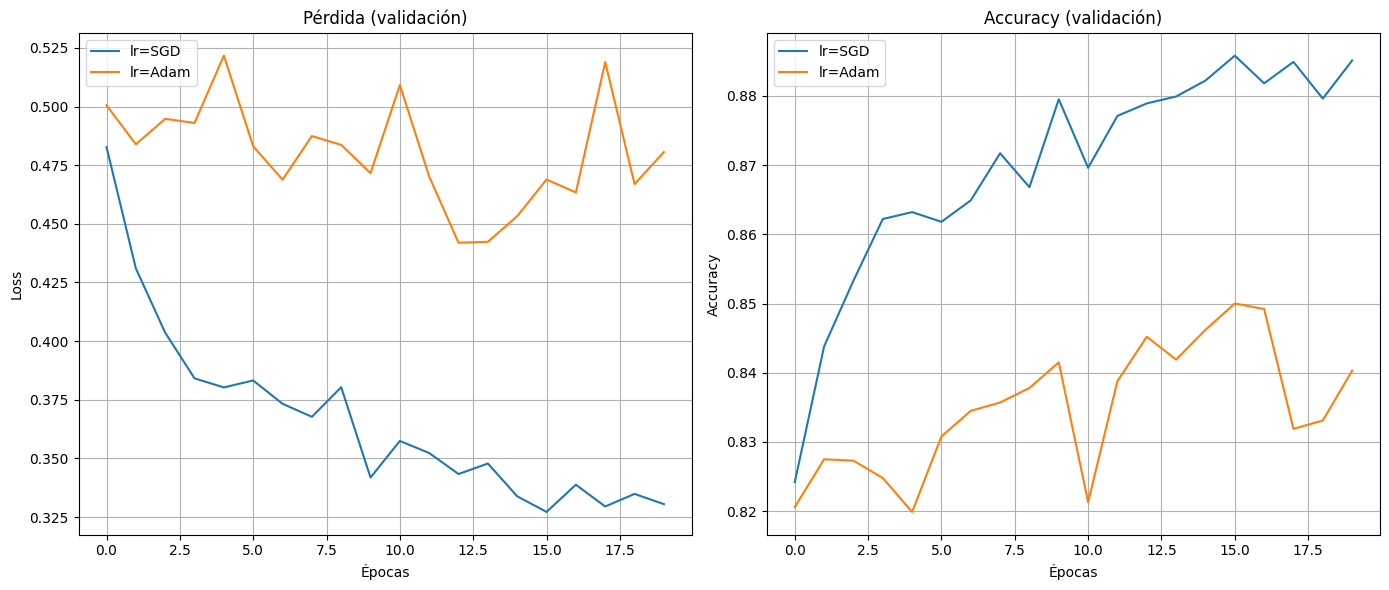

In [ ]:
#adam vs SGD con el conjunto de datos completo

optimizers_to_test = {
    "SGD": lambda params: torch.optim.SGD(params, lr=10e-3, momentum=0.9),
    "Adam": lambda params: torch.optim.Adam(params, lr=10e-3),
}

results_opt = {}
num_epochs = 20

for opt_name, opt_fn in optimizers_to_test.items():
    print(f"\nEntrenando con optimizador: {opt_name}")

    # modelo nuevo para cada optimizador
    model = FeedforwardNN().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = opt_fn(model.parameters())

    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader_completo, loss_fn, optimizer, device)
        valid_loss, valid_acc = validate(model, valid_loader_completo, loss_fn, device)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)

        print(f"  Época {epoch+1}: train_loss={train_loss:.4f}  valid_loss={valid_loss:.4f}")

    # guardar todo
    results_opt[opt_name] = {
        "train_losses": train_losses,
        "valid_losses": valid_losses,
        "train_accs": train_accs,
        "valid_accs": valid_accs,
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 fila, 2 columnas

# --- PÉRDIDA ---
for lr, data in results_opt.items():
    axes[0].plot(data["valid_losses"], label=f"lr={lr}")
axes[0].set_title("Pérdida (validación)")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid()

# --- ACCURACY ---
for lr, data in results_opt.items():
    axes[1].plot(data["valid_accs"], label=f"lr={lr}")
axes[1].set_title("Accuracy (validación)")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()




learning rates:


Entrenando con learning rate = 0.01
  Último loss de validación: 0.3359
  Última accuracy de validación: 88.01%

Entrenando con learning rate = 0.005
  Último loss de validación: 0.3713
  Última accuracy de validación: 86.40%

Entrenando con learning rate = 0.001
  Último loss de validación: 0.5026
  Última accuracy de validación: 81.46%

Entrenando con learning rate = 0.0001
  Último loss de validación: 1.0065
  Última accuracy de validación: 71.66%

Entrenando con learning rate = 1e-05
  Último loss de validación: 2.1743
  Última accuracy de validación: 42.30%


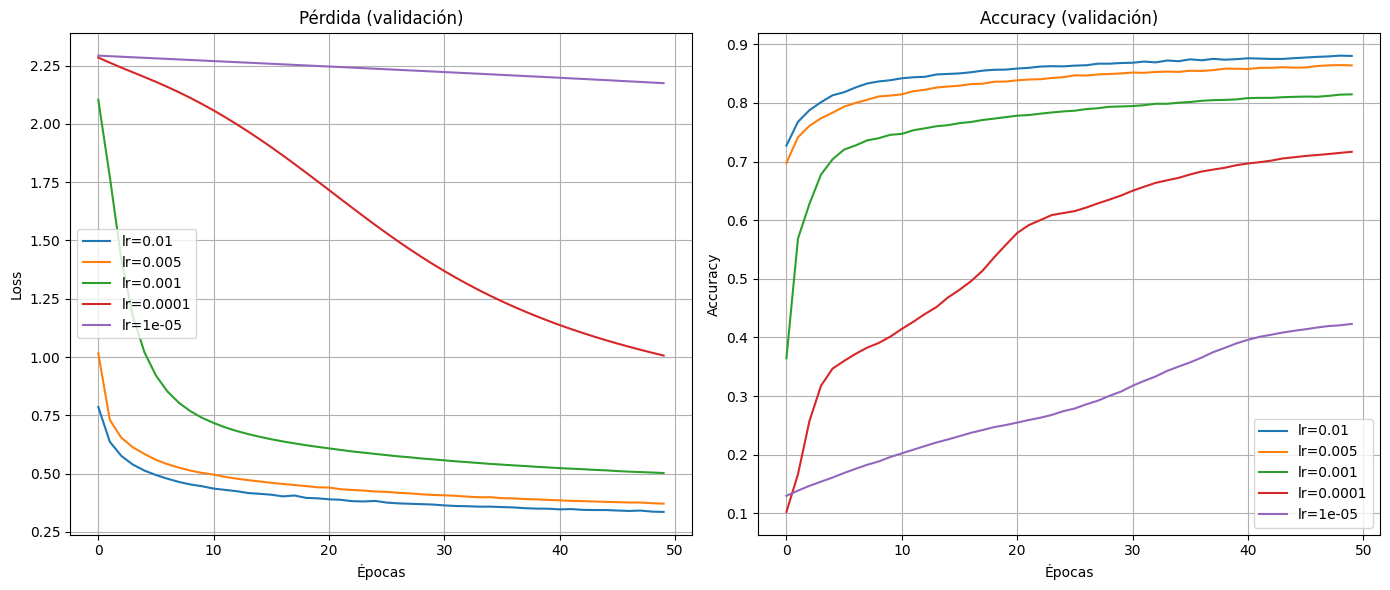

In [ ]:
learning_rates = [1e-2, 5e-3, 1e-3, 1e-4, 1e-5]
results = {}  # acá vamos a guardar las listas

for lr in learning_rates:
    print(f"\nEntrenando con learning rate = {lr}")

    model = FeedforwardNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    num_epochs = 50
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [],[]

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader_completo, loss_fn, optimizer, device)
        valid_loss, valid_acc = validate(model, valid_loader_completo, loss_fn, device)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        train_accs.append(train_acc)
        valid_accs.append(valid_acc)


    # ahora sí guardo TODA la lista
    results[lr] = {
        "train_losses": train_losses,
        "valid_losses": valid_losses,
        "train_accs": train_accs,
        "valid_accs": valid_accs,
        "best_epoch": num_epochs
    }
    print(f"  Último loss de validación: {valid_losses[-1]:.4f}")
    print(f"  Última accuracy de validación: {valid_accs[-1]*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 fila, 2 columnas

# --- PÉRDIDA ---
for lr, data in results.items():
    axes[0].plot(data["valid_losses"], label=f"lr={lr}")
axes[0].set_title("Pérdida (validación)")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid()

# --- ACCURACY ---
for lr, data in results.items():
    axes[1].plot(data["valid_accs"], label=f"lr={lr}")
axes[1].set_title("Accuracy (validación)")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


<br>

---


## <u>DIEGO</u>: Ejercicio 5)

Entrenamos el modelo

**1)** Implemente, en una función, un loop de entrenamiento que recorra los batches (lotes).

**2)** Implemente, en una función, un loop de validación que recorra los batches.

**3)** Inicialize dos `DataLoader`s llamados `train_loader` y `valid_loader` a partir del `train_set` (conjunto de entranmiento) y del `valid_set` (conjunto de validación) de Fashion-MNIST, respectivamente, y que usen batchs de 100 ejemplos.

**4)** Cree una función de pérdida usando la **Cross Entropy Loss**.

**IMPORTANTE:** Notar que la **Cross Entropy Loss** aplica automáticamente una `log_softmax`.

**5)** Cree un optimizador que utilice el método de **Stochastic Gradient Descent** con un learning rate igual a $10^{-3}$.

**6)** Cree una instancia del modelo.

**7)** Especifique en que dispositivo (`device`) va a trabajar: en una **CPU** o en una **GPU**.

**8)** Implemente un loop de entrenamiento y validación que trabaje con el `train_loader` y el `valid_loader`, respectivamente, usando un numero arbitrario de épocas.
Este loop debe guardar en cuatro listas los valores de los promedios del **Cross Entropy Loss** y las fracciones de clasificaciones correctas o **precisión** (accuracy) sobre el conjunto de **entrenamiento** y el de **validación**, respectivamente.

**IMPORTANTE:** No olvide copiar los batchs al dispositivo de trabajo.

**9)** Entrene y valide el modelo.

**10)** Use las listas del inciso anterior para graficar en función de las épocas la **Cross Entropy Loss** de **entrenamiento** y de **validación**.
Realize un gráfico análogo pero con la **precisión**.
Discuta y comente, cual es el número óptimo de épocas de entrenamiento?

**11)** Repita los experimentos variando hiperparámetros. Por ejemplo:

- El learning-rate.
- El optimizador (ej. puede usar ADAM).
- El valor de dropout.
- El número de neuronas en las capas intermedias.
- El número de épocas de entrenamiento.
- El tamaño de los lotes.

Discuta los resultados.

### *5.1)*

In [ ]:
def train_step(model, dataloader, loss_fn, optimizer):
    """
    Trains the model for ONE epoch = goes over the dataset one time using the batches.
    """
    num_batches = len(dataloader)
    model_device = next(model.parameters()).device
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Move X and y to the model device
        X, y = X.to(model_device), y.to(model_device)

        # Compute prediction and loss for the batch
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        # Backpropagate the prediction loss
        # PyTorch deposits the gradients of the loss w.r.t. each parameter.
        loss.backward()

        # Once we have our gradients, we call optimizer.step() to adjust the parameters
        # by the gradients collected in the backward pass.
        optimizer.step()

        # Reset the gradients of model parameters for the next batch
        optimizer.zero_grad()

        if batch % 100 == 0:
            print(f"Batch {batch} of {num_batches}. Loss in batch: {loss.item():.4f}")

### *5.2)*

In [ ]:
def validate_step(model, dataloader, loss_fn):
    num_batches = len(dataloader)
    size = len(dataloader.dataset)
    total_loss, total_acc = 0, 0

    model_device = next(model.parameters()).device
    model.eval()
    # For evaluating, there is no need to compute gradients
    with torch.no_grad():
        for X, y in dataloader:
            # Move X and y to the model device
            X, y = X.to(model_device), y.to(model_device)

            y_pred = model(X)
            # Compute the loss over the whole batch
            total_loss += loss_fn(y_pred, y).item()
            # Compute the amount of correct prediction in the batch
            # There is no need to apply softmax becuase softmax doesn't change
            # the relative order
            # argmax(1) finds the index of the maximum value along dimension 1
            # (the class dimension) for each row in the batch.
            total_acc += (y_pred.argmax(1) == y).type(torch.float).sum().item()

    avg_loss = total_loss / num_batches
    acc = total_acc / size

    return acc, avg_loss

### *5.3)*

In [ ]:
train_loader = DataLoader(train_set, batch_size=100, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=100, shuffle=True)

### *5.4)*

In [ ]:
loss_fn = nn.CrossEntropyLoss()

### *5.5)*

In [ ]:
learning_rate = 10e-3
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)


### 5.6)

In [ ]:
# Instanciar el modelo:
n1 = 128
n2 = 64
p = 0.2
model = FeedforwardNN(n1, n2, p)
print(model)

FeedforwardNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


### *5.7)*

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
model = model.to(device)

### 5.8) y 5.9)

In [ ]:
from tqdm.notebook import tqdm
import time
from sklearn.metrics import ConfusionMatrixDisplay

def train_validate_loop(
    model, train_loader, valid_loader, loss_fn, optimizer, epochs
):
    train_accs, train_avg_losses = [], []
    valid_accs, valid_avg_losses = [], []

    best_valid_loss = np.inf
    best_valid_acc = 0
    best_model_state = None
    patience = 20
    counter = 0
    delta = 0.0001
    early_stop = False
    best_epoch = epochs

    for epoch in tqdm(range(1, epochs+1)):
        tqdm.write(f"Epoch {epoch}")
        train_step(model, train_loader, loss_fn, optimizer)

        train_acc, train_avg_loss = validate_step(model, train_loader, loss_fn)
        valid_acc, valid_avg_loss = validate_step(model, valid_loader, loss_fn)

        tqdm.write(f"Train avg loss: {train_avg_loss:.4f} | Train accuracy: {train_acc:.4f}")
        tqdm.write(f"Valid avg loss: {valid_avg_loss:.4f} | Valid accuracy: {valid_acc:.4f}")
        tqdm.write("----------------------------------------------------------------")

        train_accs.append(train_acc)
        train_avg_losses.append(train_avg_loss)
        valid_accs.append(valid_acc)
        valid_avg_losses.append(valid_avg_loss)

        if valid_avg_loss < best_valid_loss - delta:
            best_valid_loss = valid_avg_loss
            best_valid_acc = valid_acc
            best_train_loss = train_avg_loss
            best_train_acc = train_acc
            best_model_state = model.state_dict()
            counter = 0
            best_epoch = epoch
        else:
            counter += 1
            tqdm.write(f"Patience count: {counter} of {patience}")
            if counter >= patience:
                tqdm.write(f"Early stopping at epoch {epoch}")
                early_stop = True
                break

    if early_stop:
        model.load_state_dict(best_model_state)
    else:
        best_valid_loss = valid_avg_loss
        best_valid_acc = valid_acc
        best_train_loss = train_avg_loss
        best_train_acc = train_acc
        best_epoch = epoch

    print(f"Training finished! Trained for {epoch} epochs.")
    print(
        f"Final results from epoch {best_epoch}:\n"
        f"  - Train accuracy: {best_train_acc:.4f}\n"
        f"  - Train avg loss: {best_train_loss:.4f}\n"
        f"  - Valid accuracy: {best_valid_acc:.4f}\n"
        f"  - Valid avg loss: {best_valid_loss:.4f}"
    )
    return model, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch-1

#### *Parámetros de ejecución*

In [ ]:
n1 = 128
n2 = 64
p = 0.2

model = FeedforwardNN(n1, n2, p)

learning_rate = 10e-3
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

batch_size = 100
epochs = 40

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True)

config = {
    "n1": n1,
    "n2": n2,
    "p":  p,
    "activation": "ReLU",
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "SGD"
}


best_model, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch = train_validate_loop(
    model, train_loader, valid_loader, loss_fn, optimizer, epochs
)

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1
Batch 0 of 600. Loss in batch: 2.3068
Batch 100 of 600. Loss in batch: 1.9882
Batch 200 of 600. Loss in batch: 1.5057
Batch 300 of 600. Loss in batch: 1.2358
Batch 400 of 600. Loss in batch: 1.0149
Batch 500 of 600. Loss in batch: 0.9346
Train avg loss: 0.7353 | Train accuracy: 0.7537
Valid avg loss: 0.7497 | Valid accuracy: 0.7458
----------------------------------------------------------------
Epoch 2
Batch 0 of 600. Loss in batch: 1.0091
Batch 100 of 600. Loss in batch: 0.7347
Batch 200 of 600. Loss in batch: 0.7827
Batch 300 of 600. Loss in batch: 0.6711
Batch 400 of 600. Loss in batch: 0.7389
Batch 500 of 600. Loss in batch: 0.7237
Train avg loss: 0.5984 | Train accuracy: 0.7815
Valid avg loss: 0.6181 | Valid accuracy: 0.7712
----------------------------------------------------------------
Epoch 3
Batch 0 of 600. Loss in batch: 0.6423
Batch 100 of 600. Loss in batch: 0.6818
Batch 200 of 600. Loss in batch: 0.7981
Batch 300 of 600. Loss in batch: 0.6807
Batch 400 of 600. Lo

### *5.10)*

In [ ]:
def config_metrics_plots(config, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch,
                         color=["tab:blue", "tab:orange"]):
    epochs_range = range(1, best_epoch+1)

    fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(14, 6))

    # Accuracy plot
    axes[0].plot(epochs_range, train_accs[:best_epoch], label="Entrenamiento", color=color[0])
    axes[0].plot(epochs_range, valid_accs[:best_epoch], label="Validación", color=color[1])
    axes[0].set_xlabel("Épocas")
    axes[0].set_ylabel("Precisión")
    axes[0].set_xticks(range(0, best_epoch, 5))
    axes[0].legend()
    axes[0].grid()

    # Loss plot
    axes[1].plot(epochs_range, train_avg_losses[:best_epoch], label="Entrenamiento", color=color[0])
    axes[1].plot(epochs_range, valid_avg_losses[:best_epoch], label="Validación", color=color[1])
    axes[1].set_xlabel("Épocas")
    axes[1].set_ylabel("Pérdida promedio por bache")
    axes[1].set_xticks(range(0, best_epoch, 5))
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()

    # timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    # experiment_path = os.path.join(EXPERIMENTS_PATH, f"experiment_{timestamp}")
    # os.makedirs(experiment_path, exist_ok=True)

    # with open(os.path.join(experiment_path, "config.json"), "w") as f:
    #     json.dump(config, f)

    # results = {
    #     "train_accuracy": round(train_accs[best_epoch], 4),
    #     "train_avg_loss": round(train_avg_losses[best_epoch], 4),
    #     "valid_accuracy": round(valid_accs[best_epoch], 4),
    #     "valid_avg_loss": round(valid_avg_losses[best_epoch], 4),
    #     "last_epoch": best_epoch
    # }
    # with open(os.path.join(experiment_path, "results.json"), "w") as f:
    #     json.dump(results, f)

    # fig.savefig(os.path.join(experiment_path, "metrics.png"))

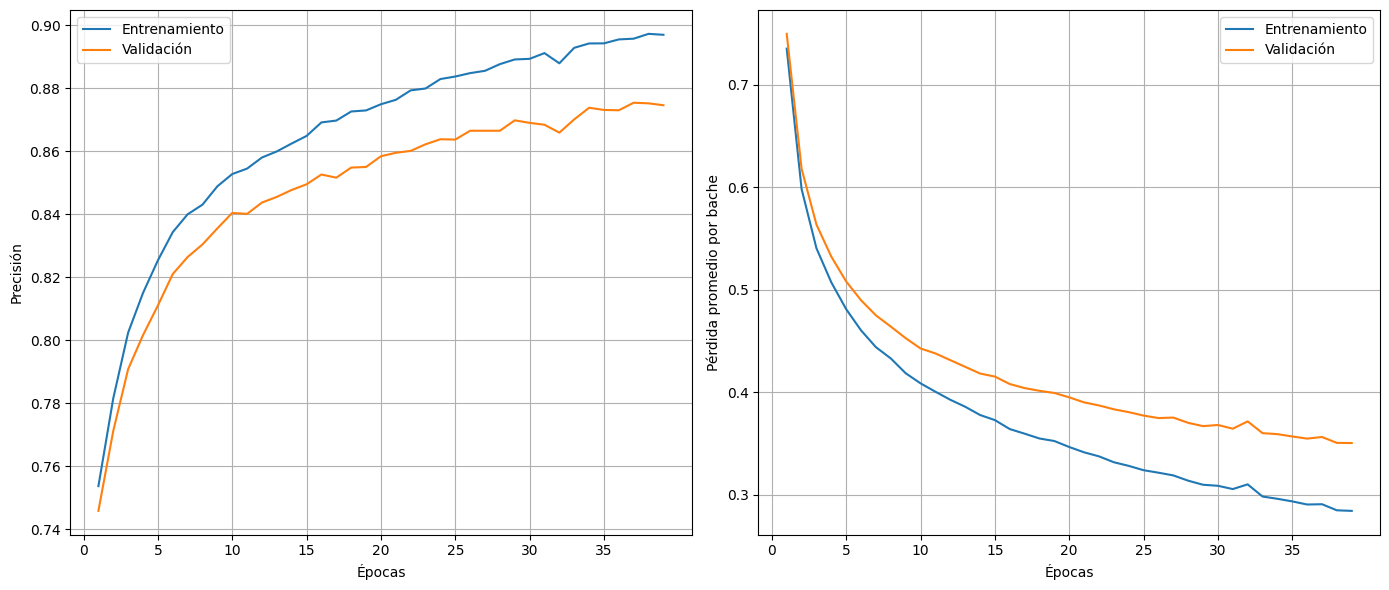

In [ ]:
config_metrics_plots(config, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch)

### *5.11)*

#### *A) Tasa de Aprendizaje*

In [ ]:
n1 = 128
n2 = 64
p = 0.2

model = FeedforwardNN(n1, n2, p)

learning_rate = 10e-4
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

batch_size = 100
epochs = 40

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True)

config = {
    "n1": n1,
    "n2": n2,
    "p":  p,
    "activation": "ReLU",
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "SGD"
}


best_model, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch = train_validate_loop(
    model, train_loader, valid_loader, loss_fn, optimizer, epochs
)

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1
Batch 0 of 600. Loss in batch: 2.3009
Batch 100 of 600. Loss in batch: 2.2774
Batch 200 of 600. Loss in batch: 2.2631
Batch 300 of 600. Loss in batch: 2.2210
Batch 400 of 600. Loss in batch: 2.2074
Batch 500 of 600. Loss in batch: 2.1726
Train avg loss: 2.1325 | Train accuracy: 0.4108
Valid avg loss: 2.1336 | Valid accuracy: 0.4109
----------------------------------------------------------------
Epoch 2
Batch 0 of 600. Loss in batch: 2.1569
Batch 100 of 600. Loss in batch: 2.1155
Batch 200 of 600. Loss in batch: 2.0677
Batch 300 of 600. Loss in batch: 1.9719
Batch 400 of 600. Loss in batch: 1.9912
Batch 500 of 600. Loss in batch: 1.9232
Train avg loss: 1.8493 | Train accuracy: 0.4766
Valid avg loss: 1.8511 | Valid accuracy: 0.4779
----------------------------------------------------------------
Epoch 3
Batch 0 of 600. Loss in batch: 1.9174
Batch 100 of 600. Loss in batch: 1.7899
Batch 200 of 600. Loss in batch: 1.8740
Batch 300 of 600. Loss in batch: 1.7068
Batch 400 of 600. Lo

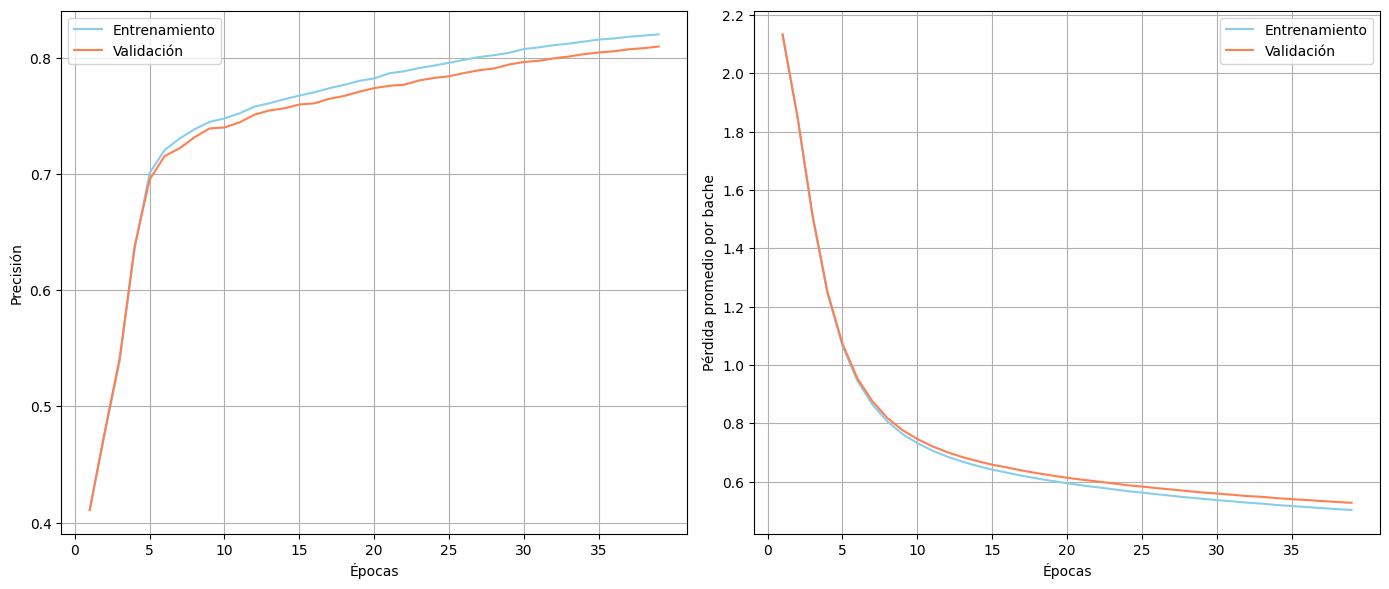

In [ ]:
config_metrics_plots(config, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch, color = ['skyblue', 'coral'])

---
#### **DEJAMOS lr=10e-4 desde acá !!!**
---

#### *B) Optimizador: Cambio a algoritmo ADAM modelo baseline*

In [ ]:
n1 = 128
n2 = 64
p = 0.2

model = FeedforwardNN(n1, n2, p)

learning_rate = 10e-4
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

batch_size = 100
epochs = 40

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True)

config = {
    "n1": n1,
    "n2": n2,
    "p":  p,
    "activation": "ReLU",
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "Adam"
}


best_model, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch = train_validate_loop(
    model, train_loader, valid_loader, loss_fn, optimizer, epochs
)

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1
Batch 0 of 600. Loss in batch: 2.2803
Batch 100 of 600. Loss in batch: 0.6872
Batch 200 of 600. Loss in batch: 0.5144
Batch 300 of 600. Loss in batch: 0.5521
Batch 400 of 600. Loss in batch: 0.5779
Batch 500 of 600. Loss in batch: 0.3310
Train avg loss: 0.4301 | Train accuracy: 0.8387
Valid avg loss: 0.4619 | Valid accuracy: 0.8286
----------------------------------------------------------------
Epoch 2
Batch 0 of 600. Loss in batch: 0.4482
Batch 100 of 600. Loss in batch: 0.5419
Batch 200 of 600. Loss in batch: 0.4645
Batch 300 of 600. Loss in batch: 0.4475
Batch 400 of 600. Loss in batch: 0.4034
Batch 500 of 600. Loss in batch: 0.5513
Train avg loss: 0.3699 | Train accuracy: 0.8652
Valid avg loss: 0.4090 | Valid accuracy: 0.8513
----------------------------------------------------------------
Epoch 3
Batch 0 of 600. Loss in batch: 0.4250
Batch 100 of 600. Loss in batch: 0.4140
Batch 200 of 600. Loss in batch: 0.3986
Batch 300 of 600. Loss in batch: 0.3794
Batch 400 of 600. Lo

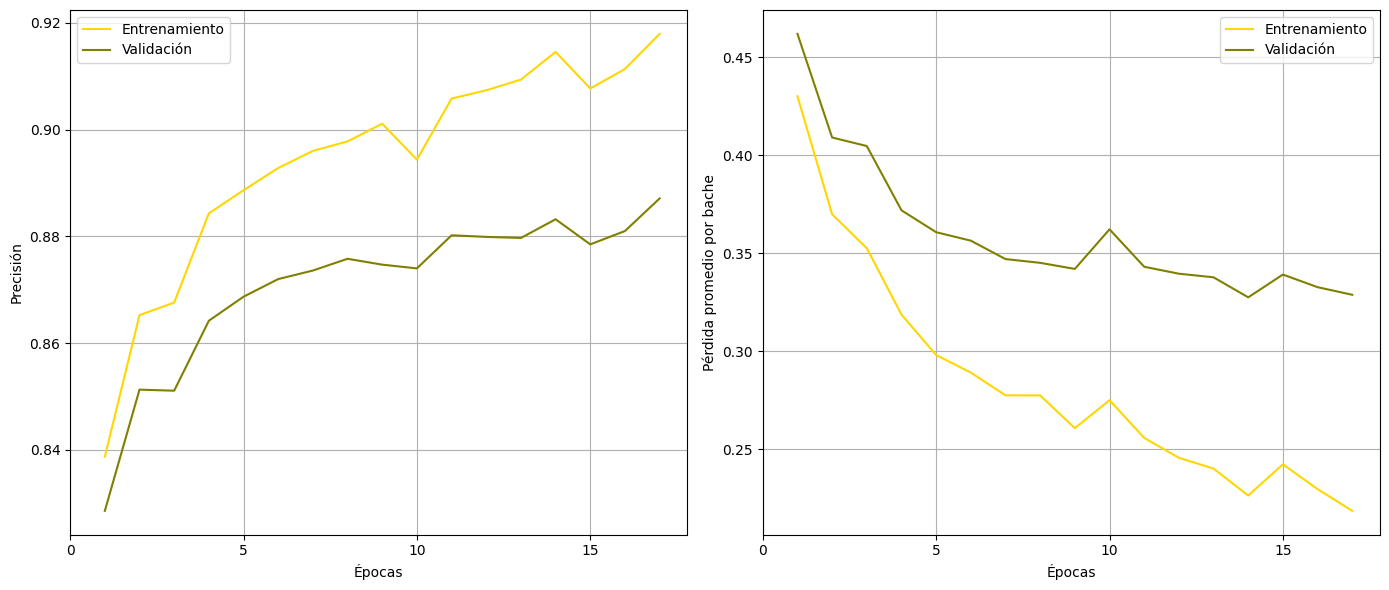

In [ ]:
config_metrics_plots(config, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch, color = ['gold', 'olive'])

#### C) *Dropout*

In [ ]:
n1 = 128
n2 = 64
p = 0.8

model = FeedforwardNN(n1, n2, p)

learning_rate = 10e-4
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

batch_size = 100
epochs = 40

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True)

config = {
    "n1": n1,
    "n2": n2,
    "p":  p,
    "activation": "ReLU",
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "SGD"
}


best_model, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch = train_validate_loop(
    model, train_loader, valid_loader, loss_fn, optimizer, epochs
)

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1
Batch 0 of 600. Loss in batch: 2.3945
Batch 100 of 600. Loss in batch: 2.3165
Batch 200 of 600. Loss in batch: 2.3046
Batch 300 of 600. Loss in batch: 2.2487
Batch 400 of 600. Loss in batch: 2.2227
Batch 500 of 600. Loss in batch: 2.2764
Train avg loss: 2.2173 | Train accuracy: 0.3599
Valid avg loss: 2.2180 | Valid accuracy: 0.3601
----------------------------------------------------------------
Epoch 2
Batch 0 of 600. Loss in batch: 2.2472
Batch 100 of 600. Loss in batch: 2.2680
Batch 200 of 600. Loss in batch: 2.2291
Batch 300 of 600. Loss in batch: 2.2063
Batch 400 of 600. Loss in batch: 2.1828
Batch 500 of 600. Loss in batch: 2.2388
Train avg loss: 2.1321 | Train accuracy: 0.3910
Valid avg loss: 2.1332 | Valid accuracy: 0.3918
----------------------------------------------------------------
Epoch 3
Batch 0 of 600. Loss in batch: 2.2098
Batch 100 of 600. Loss in batch: 2.1919
Batch 200 of 600. Loss in batch: 2.1780
Batch 300 of 600. Loss in batch: 2.1327
Batch 400 of 600. Lo

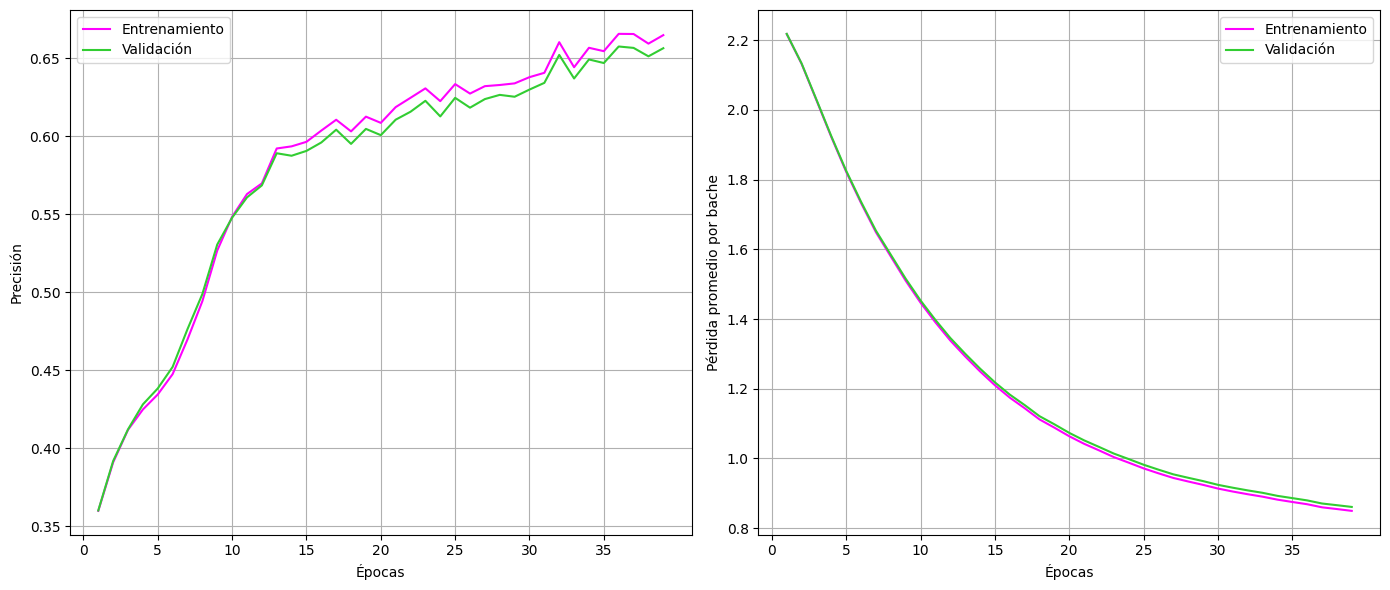

In [ ]:
config_metrics_plots(config, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch, color = ['fuchsia', 'limegreen'])

#### *D) Nº de neuronas en capas intermedias*

In [ ]:
n1 = 256
n2 = 128
p = 0.2

model = FeedforwardNN(n1, n2, p)

learning_rate = 10e-4
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

batch_size = 100
epochs = 40

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True)

config = {
    "n1": n1,
    "n2": n2,
    "p":  p,
    "activation": "ReLU",
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "SGD"
}


best_model, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch = train_validate_loop(
    model, train_loader, valid_loader, loss_fn, optimizer, epochs
)

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1
Batch 0 of 600. Loss in batch: 2.3120
Batch 100 of 600. Loss in batch: 2.2847
Batch 200 of 600. Loss in batch: 2.2498
Batch 300 of 600. Loss in batch: 2.2233
Batch 400 of 600. Loss in batch: 2.1982
Batch 500 of 600. Loss in batch: 2.1424
Train avg loss: 2.0862 | Train accuracy: 0.5064
Valid avg loss: 2.0877 | Valid accuracy: 0.4998
----------------------------------------------------------------
Epoch 2
Batch 0 of 600. Loss in batch: 2.0909
Batch 100 of 600. Loss in batch: 2.0348
Batch 200 of 600. Loss in batch: 1.9910
Batch 300 of 600. Loss in batch: 1.9323
Batch 400 of 600. Loss in batch: 1.8268
Batch 500 of 600. Loss in batch: 1.8506
Train avg loss: 1.7090 | Train accuracy: 0.5787
Valid avg loss: 1.7121 | Valid accuracy: 0.5803
----------------------------------------------------------------
Epoch 3
Batch 0 of 600. Loss in batch: 1.7754
Batch 100 of 600. Loss in batch: 1.6429
Batch 200 of 600. Loss in batch: 1.5742
Batch 300 of 600. Loss in batch: 1.4957
Batch 400 of 600. Lo

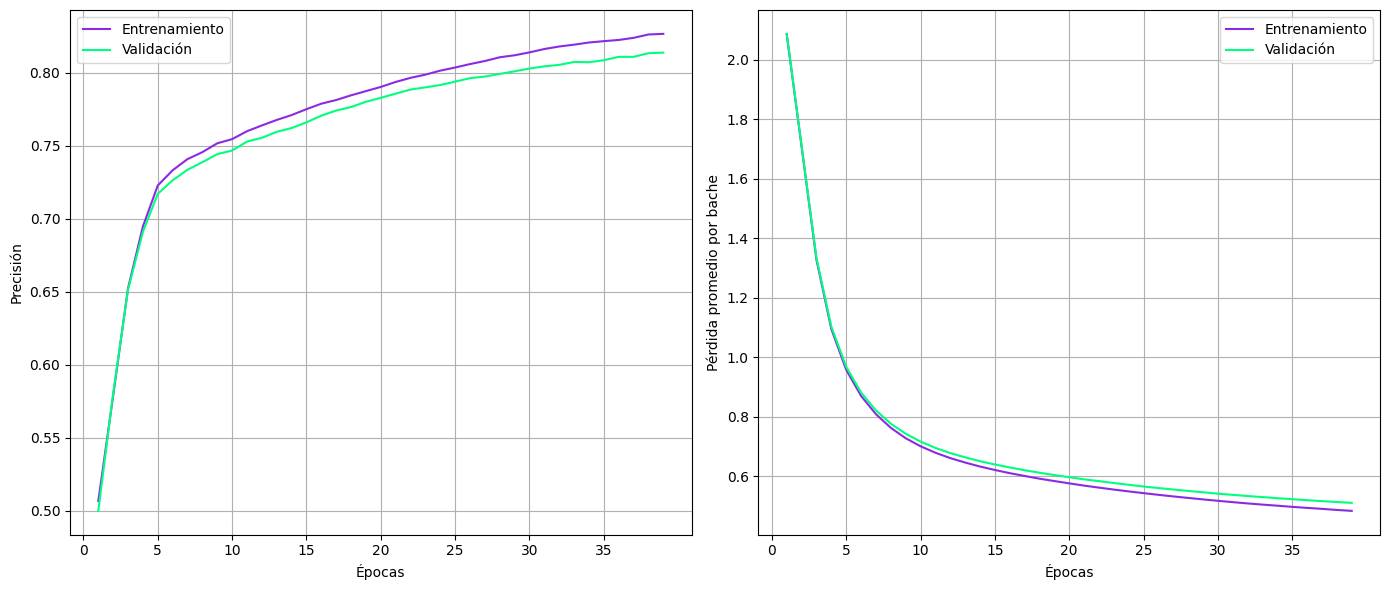

In [ ]:
config_metrics_plots(config, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch, color = ['blueviolet', 'springgreen'])

#### *E) Nº de epochs*

In [ ]:
n1 = 128
n2 = 64
p = 0.2

model = FeedforwardNN(n1, n2, p)

learning_rate = 10e-4
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

batch_size = 100
epochs = 100

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True)

config = {
    "n1": n1,
    "n2": n2,
    "p":  p,
    "activation": "ReLU",
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "SGD"
}


best_model, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch = train_validate_loop(
    model, train_loader, valid_loader, loss_fn, optimizer, epochs
)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1
Batch 0 of 600. Loss in batch: 2.3172
Batch 100 of 600. Loss in batch: 2.2764
Batch 200 of 600. Loss in batch: 2.2564
Batch 300 of 600. Loss in batch: 2.2029
Batch 400 of 600. Loss in batch: 2.1833
Batch 500 of 600. Loss in batch: 2.1371
Train avg loss: 2.0863 | Train accuracy: 0.3641
Valid avg loss: 2.0872 | Valid accuracy: 0.3620
----------------------------------------------------------------
Epoch 2
Batch 0 of 600. Loss in batch: 2.1222
Batch 100 of 600. Loss in batch: 2.0410
Batch 200 of 600. Loss in batch: 1.9797
Batch 300 of 600. Loss in batch: 2.0255
Batch 400 of 600. Loss in batch: 1.8984
Batch 500 of 600. Loss in batch: 1.8317
Train avg loss: 1.7524 | Train accuracy: 0.4374
Valid avg loss: 1.7547 | Valid accuracy: 0.4373
----------------------------------------------------------------
Epoch 3
Batch 0 of 600. Loss in batch: 1.8894
Batch 100 of 600. Loss in batch: 1.7774
Batch 200 of 600. Loss in batch: 1.7459
Batch 300 of 600. Loss in batch: 1.6508
Batch 400 of 600. Lo

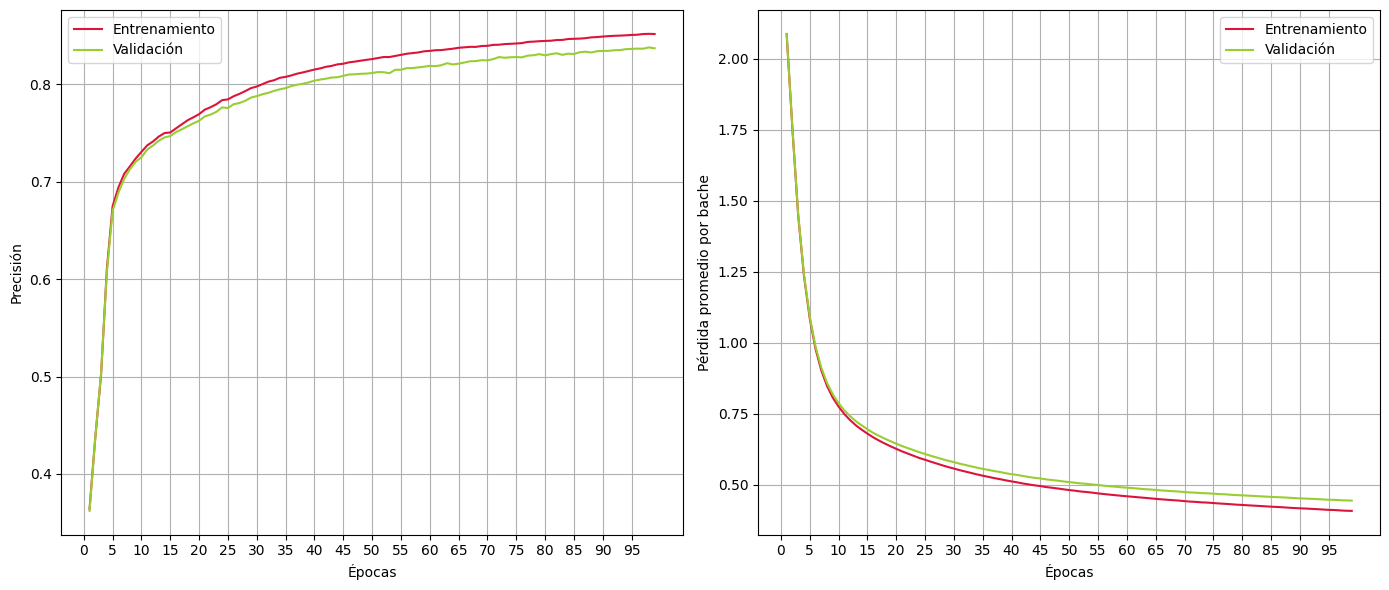

In [ ]:
config_metrics_plots(config, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch, color = ['crimson', 'yellowgreen'])

#### *F) Tamaño de los lotes*

In [ ]:
n1 = 128
n2 = 64
p = 0.2

model = FeedforwardNN(n1, n2, p)

learning_rate = 10e-4
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

batch_size = 200
epochs = 40

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True)

config = {
    "n1": n1,
    "n2": n2,
    "p":  p,
    "activation": "ReLU",
    "learning_rate": learning_rate,
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "SGD"
}


best_model, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch = train_validate_loop(
    model, train_loader, valid_loader, loss_fn, optimizer, epochs
)

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1
Batch 0 of 300. Loss in batch: 2.3140
Batch 100 of 300. Loss in batch: 2.2811
Batch 200 of 300. Loss in batch: 2.2479
Train avg loss: 2.2156 | Train accuracy: 0.2962
Valid avg loss: 2.2173 | Valid accuracy: 0.2884
----------------------------------------------------------------
Epoch 2
Batch 0 of 300. Loss in batch: 2.2114
Batch 100 of 300. Loss in batch: 2.1843
Batch 200 of 300. Loss in batch: 2.1770
Train avg loss: 2.0970 | Train accuracy: 0.4801
Valid avg loss: 2.0996 | Valid accuracy: 0.4745
----------------------------------------------------------------
Epoch 3
Batch 0 of 300. Loss in batch: 2.1257
Batch 100 of 300. Loss in batch: 2.0408
Batch 200 of 300. Loss in batch: 2.0536
Train avg loss: 1.9296 | Train accuracy: 0.5256
Valid avg loss: 1.9330 | Valid accuracy: 0.5236
----------------------------------------------------------------
Epoch 4
Batch 0 of 300. Loss in batch: 1.9419
Batch 100 of 300. Loss in batch: 1.9084
Batch 200 of 300. Loss in batch: 1.8385
Train avg los

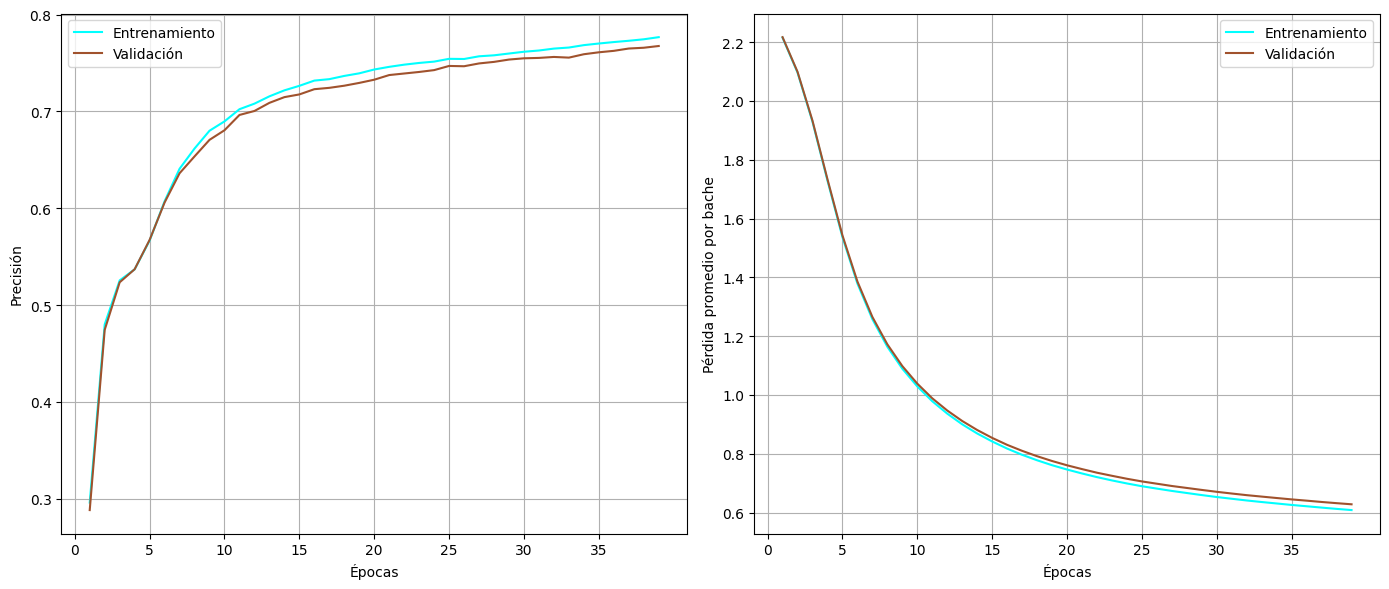

In [ ]:
config_metrics_plots(config, train_accs, train_avg_losses, valid_accs, valid_avg_losses, best_epoch, color = ['aqua', 'sienna'])